# DiSCo Python Test
Dieses Notebook testet die übersetzte Python-Version (`disco.py`) mit dem `dube` Datensatz, der auch in der R-Vignette (`Dube2019.Rmd`) verwendet wird.

In [10]:
import pandas as pd
import numpy as np
import pyreadr
import sys
import os
import matplotlib.pyplot as plt

# Pfad hinzufügen, damit wir als Modul importieren können
sys.path.append(os.path.abspath('..'))

from python.disco import DiSCo

## 1. Dube (2019) Daten laden
Wir laden die Daten aus dem R-Package `data/dube.rda`. Laut der Vignette wird `state=2` als Treatment betrachtet und `t0=2003`.

In [11]:
# Lade die originale R-Datei
result_rda = pyreadr.read_r('../data/dube.rda')
df_raw = result_rda['dube']

# Spalten passend für DiSCo umbenennen
df = df_raw.copy()
df = df.rename(columns={
    'fips': 'id_col',
    'year': 'time_col',
    'adj0contpov': 'y_col'
})

print(f"Datensatz geladen: {len(df)} Zeilen")
df.head()

Datensatz geladen: 652870 Zeilen


,time_col,id_col,y_col
0,1998.0,1.0,2.791217
1,1998.0,1.0,0.165951
2,1998.0,1.0,1.674730
3,1998.0,1.0,2.088006
4,1998.0,1.0,3.639715


In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

n = 1000
multi_co_df = df.groupby(['time_col', 'id_col'])['y_col'].apply(
    lambda x: np.random.choice(x, size=n, replace=True) if len(x) >= n else x
).reset_index(name='y_array')

for period in sorted(multi_co_df['time_col'].unique()):
    print(f"Zeitperiode t={period}:")
    period_data = multi_co_df[multi_co_df['time_col'] == period]
    period_data = np.column_stack(period_data['y_array'])
    vifs = pd.Series([variance_inflation_factor(period_data, i) 
                      for i in range(period_data.shape[1])])
    print(np.max(vifs))


Zeitperiode t=1998.0:
2.746036155419912
Zeitperiode t=1999.0:
2.403668022376312
Zeitperiode t=2000.0:
2.6667497785870378
Zeitperiode t=2001.0:
2.5141144754362177
Zeitperiode t=2002.0:
2.704928501147373
Zeitperiode t=2003.0:
2.4662738560024846
Zeitperiode t=2004.0:
2.7386713217134933


In [13]:
print("Initialisiere DiSCo mit Dube-Daten...")  
disco_model = DiSCo(
    df=df,
    id_col='id_col',
    time_col='time_col',
    y_col='y_col',
    id_col_target=2,     # FIPS = 2 (Alaska) als Treatment
    t0=2003,             # Treatment im Jahr 2003
    M=1000,              # Monte Carlo Draws 
    G=1000,              # Grid Size
    num_cores=1,        # Alle CPU-Kerne für maximalen Speed nutzen
    simplex=True,        # Entspricht den Parametern in der Vignette
    q_max=0.9,            # Entspricht den Parametern in der Vignette
    CI=True,             # Bootstrap-Konfidenzintervalle berechnen
    cl=0.95,             # Konfidenzniveau für Intervalle
    uniform=False,
    perm=True
)

result = disco_model.fit()

Initialisiere DiSCo mit Dube-Daten...


In [14]:
pd.Series(result.weights, index=disco_model.controls_id).sort_values(ascending=False).head(5)

39.0    0.168988
29.0    0.142100
45.0    0.086906
26.0    0.065791
51.0    0.058177
dtype: float64

In [15]:
if result.CI is not None and result.CI.quantile is not None:
    for i in range(7):
        overview = pd.DataFrame({
            'lower': result.CI.quantile.lower[:, i],
            'upper': result.CI.quantile.upper[:, i],
            'se':    result.CI.quantile.se[:, i]
        }, index=result.evgrid)
        print(f'Time Period t={i+1}:')
        print(f"{overview['se'].median()}")

Time Period t=1:
0.03145507419628639
Time Period t=2:
0.03664028855554177
Time Period t=3:
0.032113143971499114
Time Period t=4:
0.03256916028751308
Time Period t=5:
0.033507058679001174
Time Period t=6:
0.039156213993077095
Time Period t=7:
0.0398958287180462


In [16]:
(result.perm.p_overall)

np.float64(0.20588235294117646)


Call:
DiSCoTEA

--- Treatment Effects ---
 Time  X_from  X_to  Quantile Delta  Std. Error   [95%   Conf. Band] Sig
 2003     0.0   0.9         -0.0518      0.0461 -0.1329       0.0607    
 2004     0.0   0.9         -0.1481      0.0463 -0.2412      -0.0780   *

--- Permutation Test ---
p-value: 0.2059

None


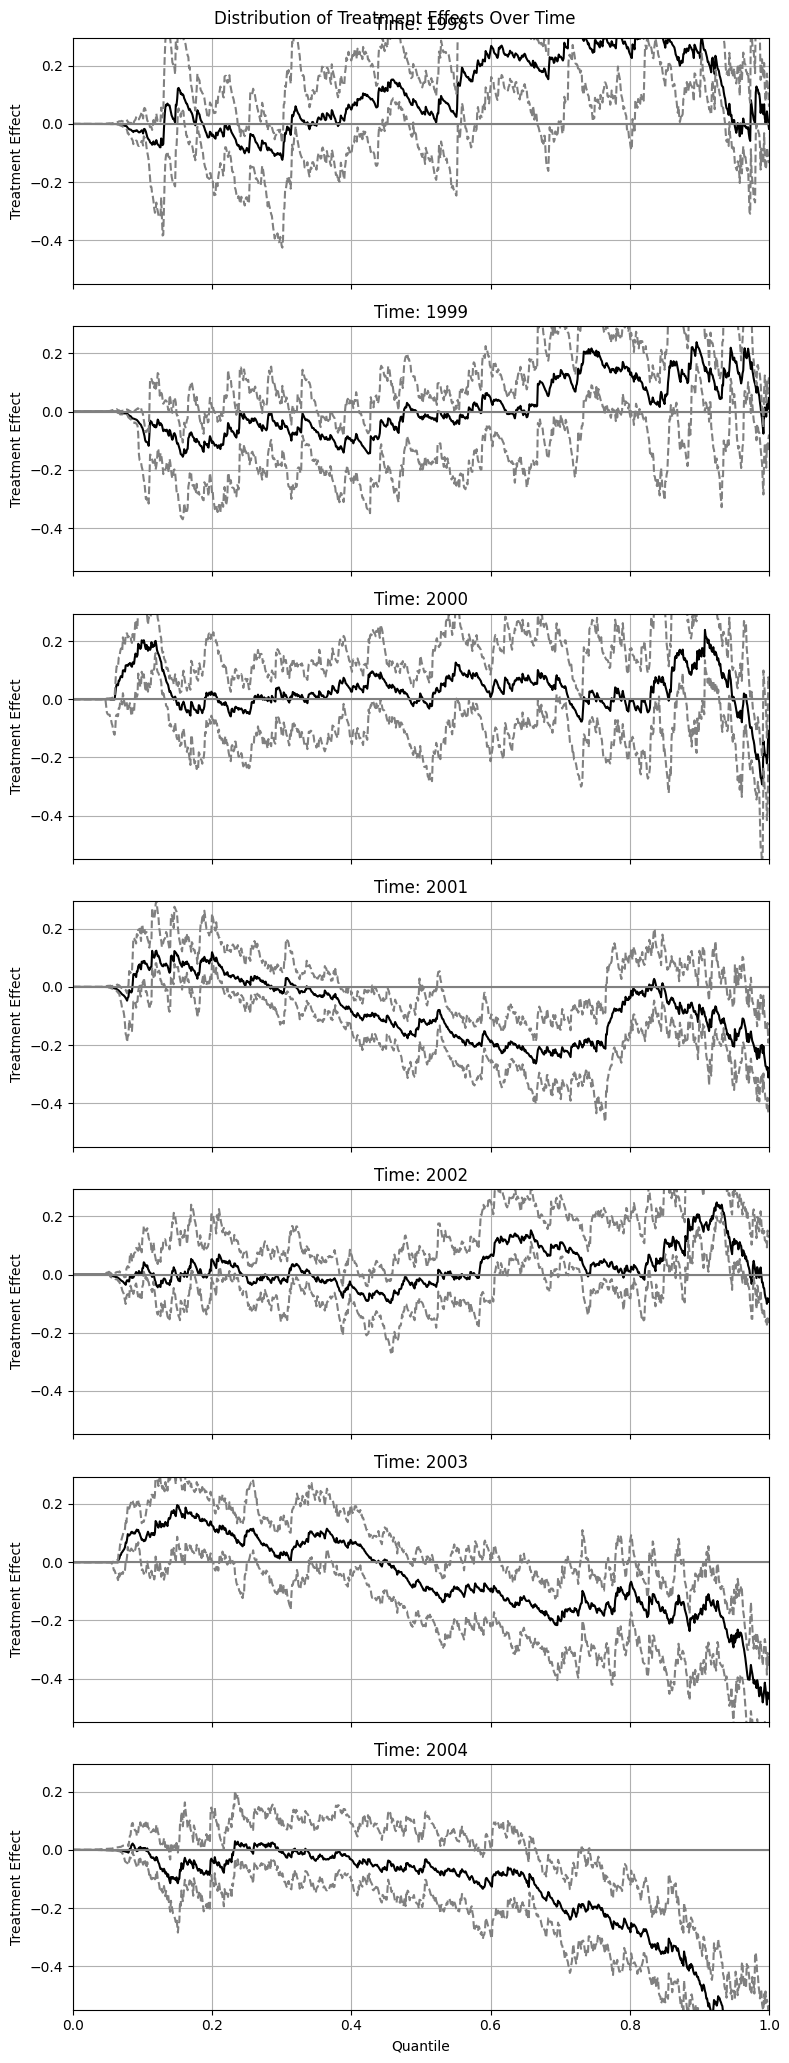

In [17]:
from python.tea import disco_tea
tea_res = disco_tea(result, agg="quantileDiff", graph=True)
print(tea_res.summary())


Call:
DiSCoTEA

--- Treatment Effects ---
 Time  X_from  X_to  CDF Delta  Std. Error   [95%   Conf. Band] Sig
 2003     0.0   0.9     0.0047      0.0047 -0.0065       0.0131    
 2004     0.0   0.9     0.0172      0.0050  0.0096       0.0273   *

--- Permutation Test ---
p-value: 0.2059

None


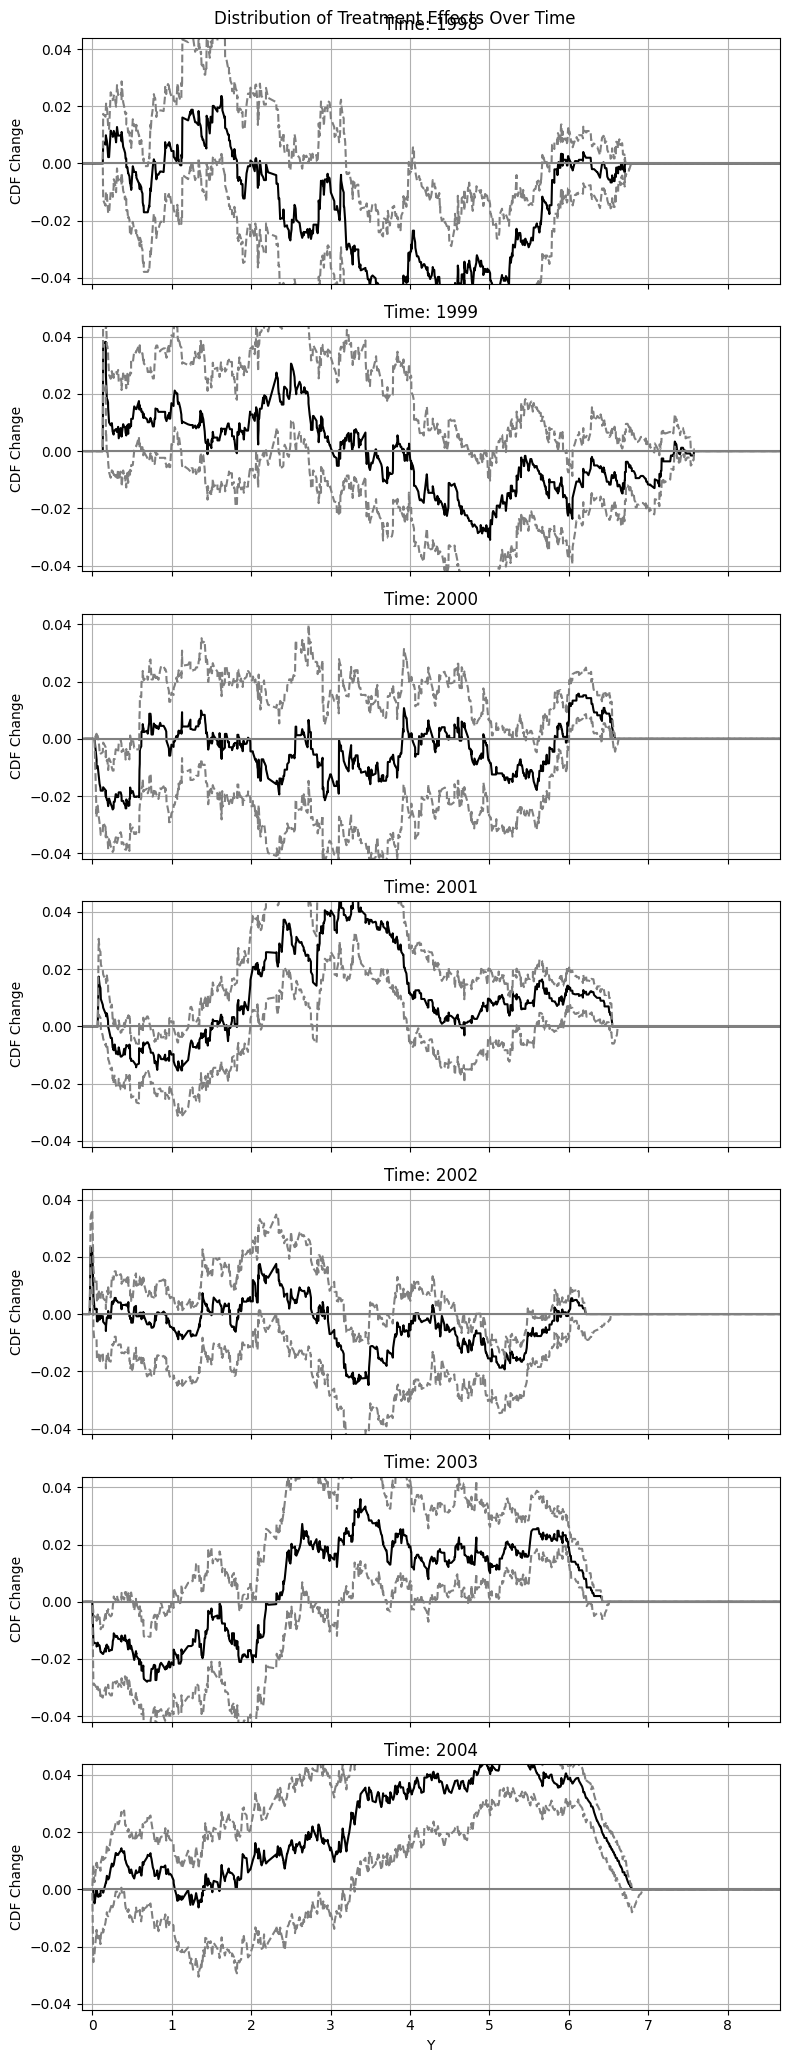

In [19]:
tea_res_2 = disco_tea(result, agg="cdfDiff", graph=True)
print(tea_res_2.summary())